# Data Preprocessing

In this notebook, we clean the data: handle missing values, detect and treat outliers, and prepare for further processing.

In [1]:
# Imports
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/Train.csv')
print('Original shape:', df.shape)
df.head()

Original shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [2]:
# Check for missing values
print('Missing values:')
print(df.isnull().sum())

# Since there are no missing values in this dataset, we can skip imputation
# But let's demonstrate KNN imputer for completeness
imputer = KNNImputer(n_neighbors=5)
# If there were missing, df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

Missing values:
ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [3]:
# Outlier detection using IQR
numerical_cols = ['Customer_care_calls', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms']

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

for col in numerical_cols:
    outliers, lb, ub = detect_outliers_iqr(df, col)
    print(f'{col}: {len(outliers)} outliers, bounds: {lb:.2f} to {ub:.2f}')

Customer_care_calls: 0 outliers, bounds: 0.00 to 8.00
Cost_of_the_Product: 0 outliers, bounds: 46.00 to 374.00
Prior_purchases: 1003 outliers, bounds: 1.50 to 5.50
Discount_offered: 2209 outliers, bounds: -5.00 to 19.00
Weight_in_gms: 0 outliers, bounds: -2976.25 to 9865.75


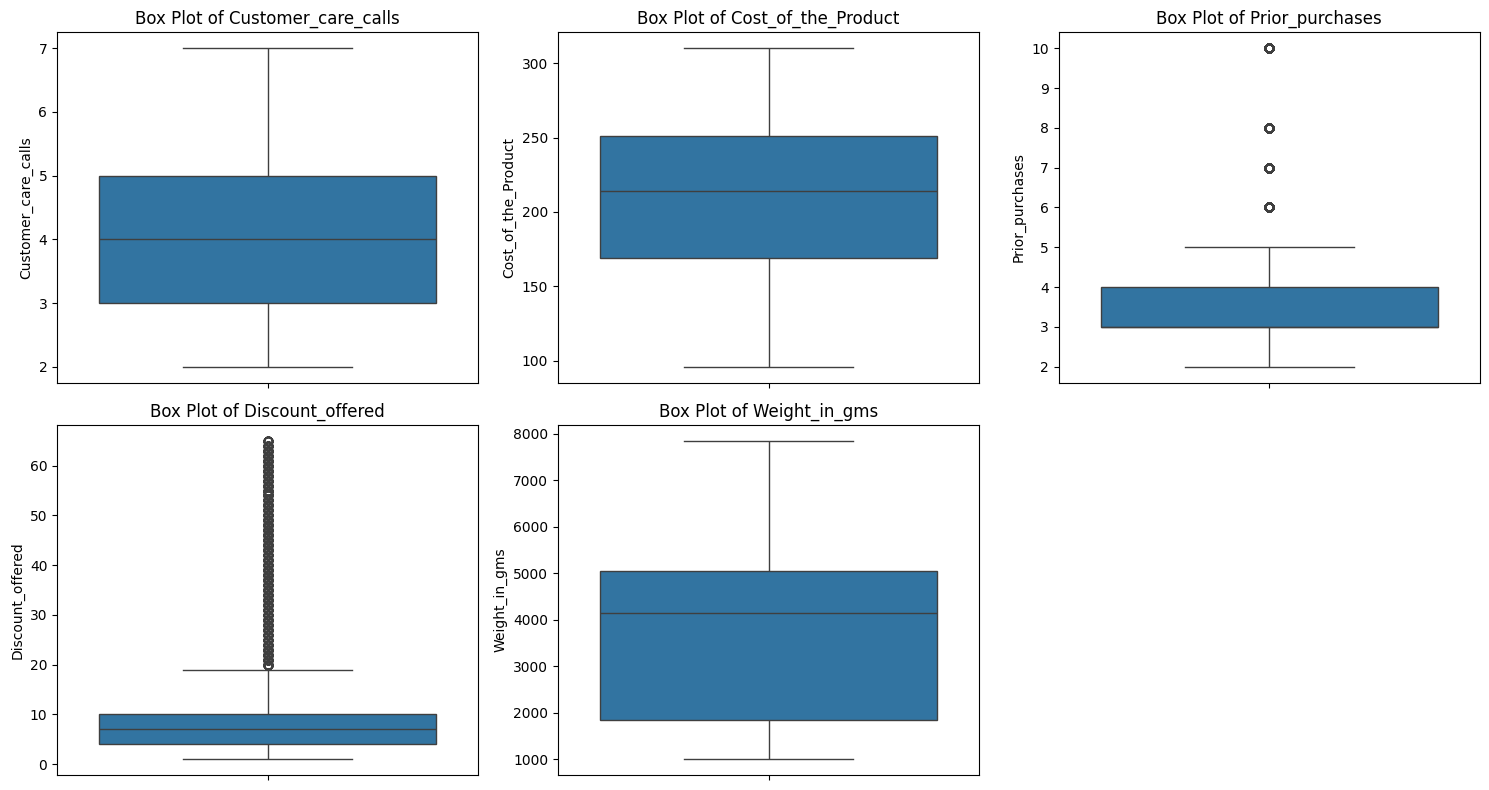

In [4]:
# Visualize outliers with box plots
plt.figure(figsize=(15,8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

In [5]:
# Handle outliers: Cap them at bounds
df_clean = df.copy()
for col in numerical_cols:
    outliers, lb, ub = detect_outliers_iqr(df, col)
    df_clean[col] = np.where(df_clean[col] < lb, lb, df_clean[col])
    df_clean[col] = np.where(df_clean[col] > ub, ub, df_clean[col])
    print(f'Capped {len(outliers)} outliers in {col}')

print('After outlier treatment shape:', df_clean.shape)

Capped 0 outliers in Customer_care_calls
Capped 0 outliers in Cost_of_the_Product
Capped 1003 outliers in Prior_purchases
Capped 2209 outliers in Discount_offered
Capped 0 outliers in Weight_in_gms
After outlier treatment shape: (10999, 12)


In [6]:
# Scaling numerical features
# Use RobustScaler since we have outliers
scaler = RobustScaler()
df_clean[numerical_cols] = scaler.fit_transform(df_clean[numerical_cols])
print('Numerical features scaled with RobustScaler')

# Check scaled data
df_clean[numerical_cols].describe()

Numerical features scaled with RobustScaler


,Customer_care_calls,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms
count,10999.000000,10999.000000,10999.000000,10999.00000,10999.000000
mean,0.027230,-0.046380,0.421629,0.26516,-0.160406
std,0.570745,0.586137,1.136903,1.01591,0.509384
min,-1.000000,-1.439024,-1.000000,-1.00000,-0.980533
25%,-0.500000,-0.548780,0.000000,-0.50000,-0.719358
50%,0.000000,0.000000,0.000000,0.00000,0.000000
75%,0.500000,0.451220,1.000000,0.50000,0.280642
max,1.500000,1.170732,2.500000,2.00000,1.151534


In [7]:
# Save preprocessed data
df_clean.to_csv('../data/preprocessed_data.csv', index=False)
print('Preprocessed data saved to ../data/preprocessed_data.csv')

Preprocessed data saved to ../data/preprocessed_data.csv
